In [55]:
import pandas as pd
df = pd.read_csv('/home/shawky/Documents/nti/actual nti/wine naiive bayes/WineQT.csv')

In [56]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595


In [57]:
df.drop(columns=['Id'], inplace=True)

In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 107.3 KB


The data has no categorical cols, all numerical

In [59]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [60]:
df.duplicated().sum()

np.int64(125)

In [61]:
df.drop_duplicates(inplace=True)

In [62]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000
mean,8.288507,0.533541,0.268802,2.524411,0.087187,15.648821,46.325639,0.996700,3.311503,0.656817,10.452456,5.641454
std,1.741324,0.183167,0.196229,1.314850,0.048506,10.176525,33.123533,0.001916,0.157775,0.167542,1.095064,0.811744
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,21.000000,0.995572,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,38.000000,0.996665,3.310000,0.620000,10.200000,6.000000
75%,9.100000,0.645000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997827,3.400000,0.720000,11.200000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


from normal eye inspection i can tell that citric acid has outliers, as well as residual sugar, clorides, sulferdioxide, total sulfer dioxide, sulphates


In [63]:
from feature_engine.outliers import OutlierTrimmer

trimmer = OutlierTrimmer(capping_method='iqr', tail='both', fold=1.5)
trimmer

,capping_method,'iqr'
,tail,'both'
,fold,1.5
,variables,None
,missing_values,'raise'


there is a function that gets us outliers instantly without having to defining one

however we wont apply it now, we first want to check skewness and data imbalance then split and treat each one using its own method

In [64]:
skewness = df.skew()
skewness

fixed acidity           1.037193
volatile acidity        0.719668
citric acid             0.368824
residual sugar          4.350318
chlorides               5.933225
free sulfur dioxide     1.172090
total sulfur dioxide    1.680327
density                 0.091874
pH                      0.257993
sulphates               2.424667
alcohol                 0.848859
quality                 0.277656
dtype: float64

In [65]:
skewed_features = skewness[skewness > 0.7].index
skewed_features.tolist()

['fixed acidity',
 'volatile acidity',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'sulphates',
 'alcohol']

/tmp/ipykernel_33196/3120472654.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=skew_vals.values, y=skew_vals.index, palette='Blues_r')


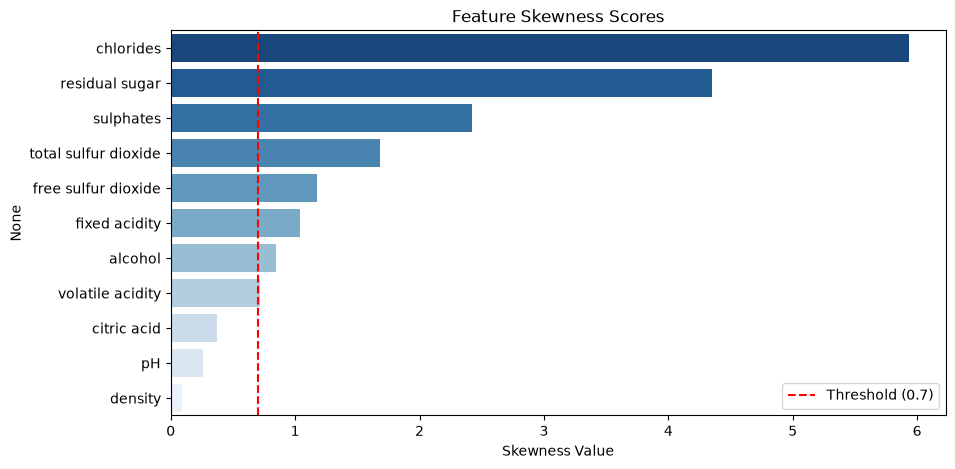

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

skew_vals = df.drop(columns=['quality']).skew().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=skew_vals.values, y=skew_vals.index, palette='Blues_r')

plt.axvline(x=0.7, color='red', linestyle='--', label='Threshold (0.7)')

plt.title('Feature Skewness Scores')
plt.xlabel('Skewness Value')
plt.legend()
plt.show()

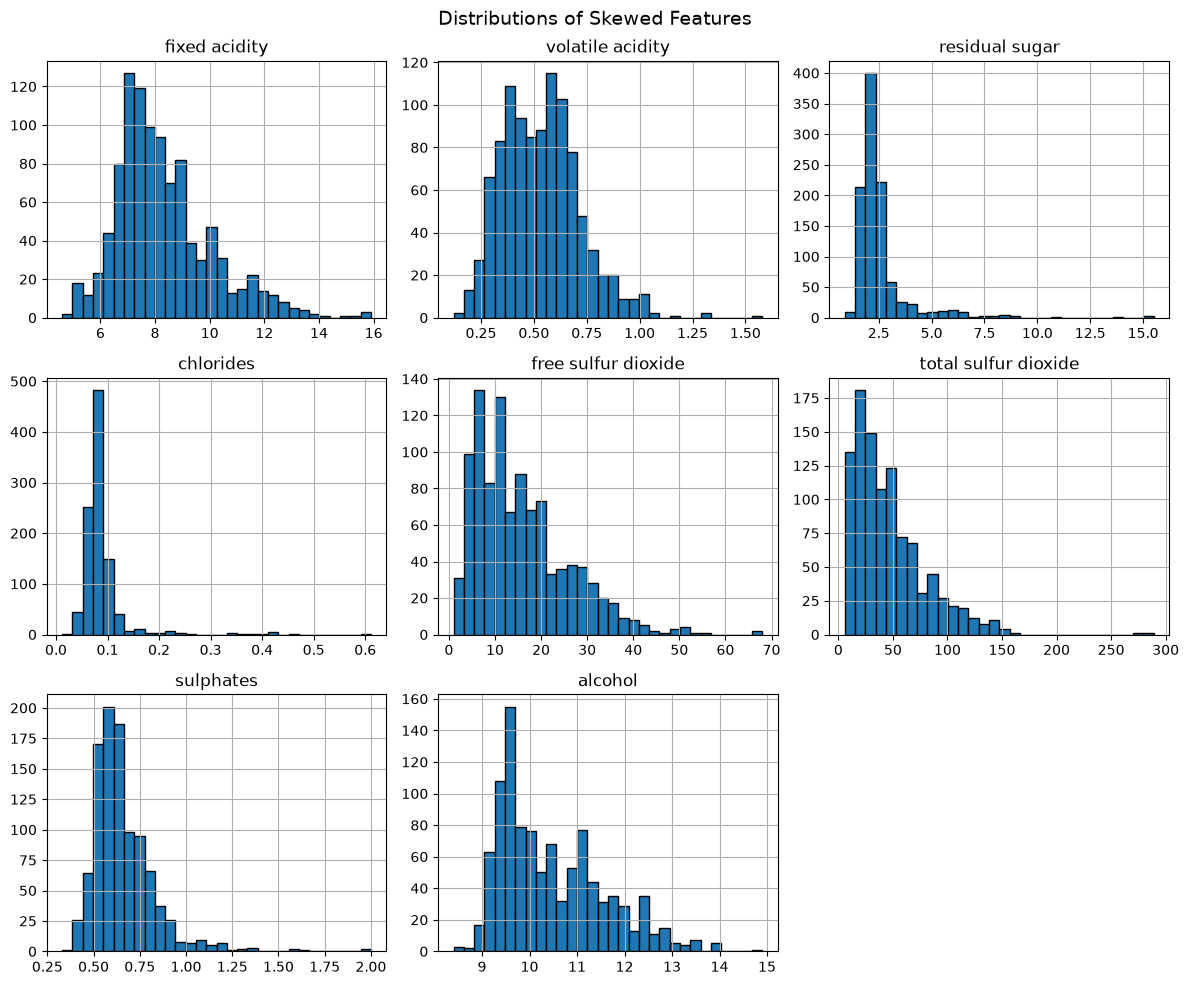

In [67]:
df[skewed_features].hist(figsize=(12, 10), bins=30, edgecolor='black')
plt.suptitle('Distributions of Skewed Features', fontsize=14)
plt.tight_layout()
plt.show()

checking imbalance:

In [68]:
quality_counts = df['quality'].value_counts()

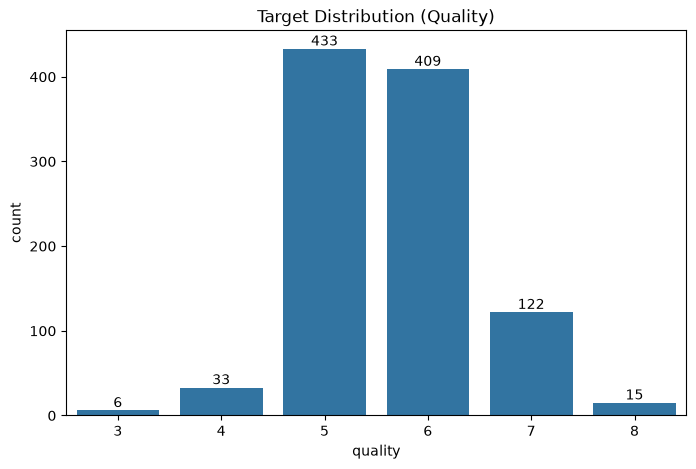

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
ax = sns.countplot(x='quality', data=df)
plt.title('Target Distribution (Quality)')


for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10)

plt.show()

now we start out train test split

In [70]:
from sklearn.model_selection import StratifiedKFold


X = df.drop(columns=['quality'])
y = df['quality']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_train, y_test = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()

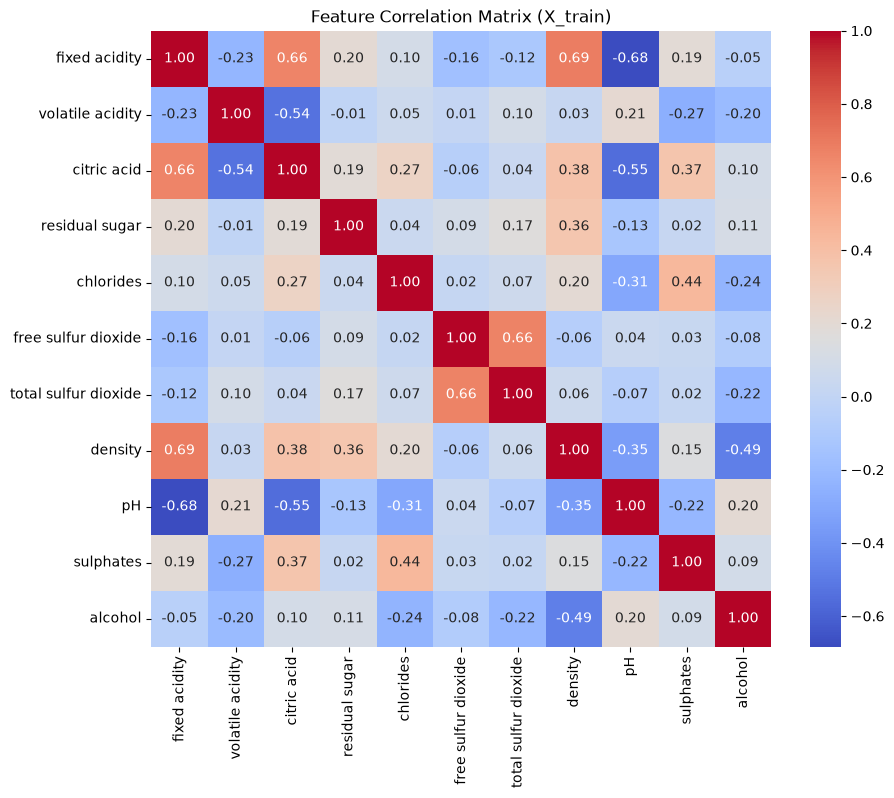

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(X_train.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Matrix (X_train)')
plt.show()

i will start with trimming outliers

In [72]:
X_train_clean = trimmer.fit_transform(X_train)
y_train_clean = y_train.loc[X_train_clean.index]


here i am removing outliers from x and i am removing the same indeces from y

now for skewness:

In [73]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')
X_train_clean[skewed_features] = pt.fit_transform(X_train_clean[skewed_features])
X_test[skewed_features] = pt.transform(X_test[skewed_features])

now i want to handle data imbalance using SMOTEENN, and to use that i have to ecale first cuz it uses edited nearest neighbors which is distance based

In [74]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_clean)

X_test_scaled = scaler.transform(X_test)

In [75]:
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, k_neighbors=1)
smote_enn = SMOTEENN(smote = smote, random_state=42)
X_train_resampled, y_train_resampled = smote_enn.fit_resample(X_train_scaled, y_train_clean)

well this part was tricky, because we have a class with only 2 samples the smote didnt work as by default it needs atleast 6 samples because it works with k = 5 so i had to manually modify that to k = 1

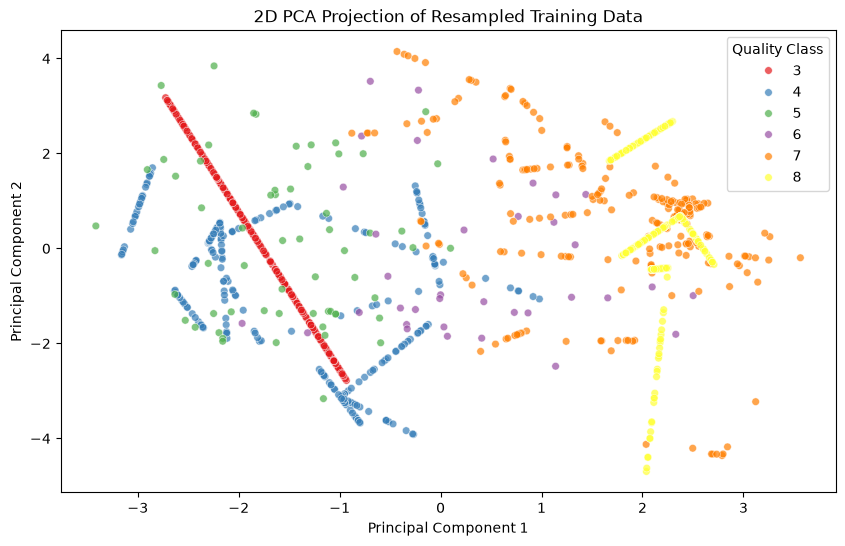

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Compress features into 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_resampled)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_pca[:, 0], 
    y=X_pca[:, 1], 
    hue=y_train_resampled, 
    palette='Set1', 
    alpha=0.7,
    s=30
)

plt.title('2D PCA Projection of Resampled Training Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Quality Class')
plt.show()

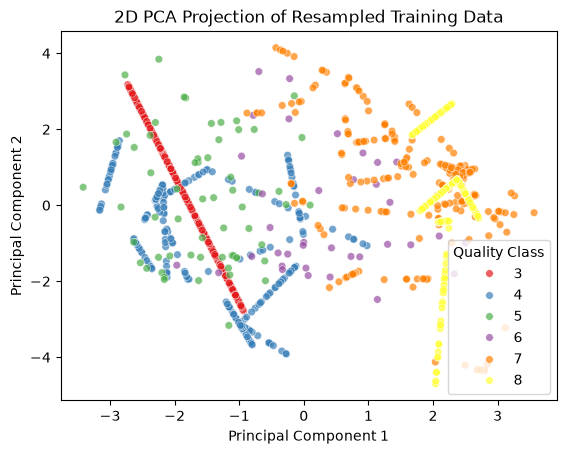

In [77]:
sns.scatterplot(
    x=X_pca[:, 0], 
    y=X_pca[:, 1], 
    hue=y_train_resampled, 
    palette='Set1', 
    alpha=0.7,
    s=30
)

plt.title('2D PCA Projection of Resampled Training Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Quality Class')
plt.show()

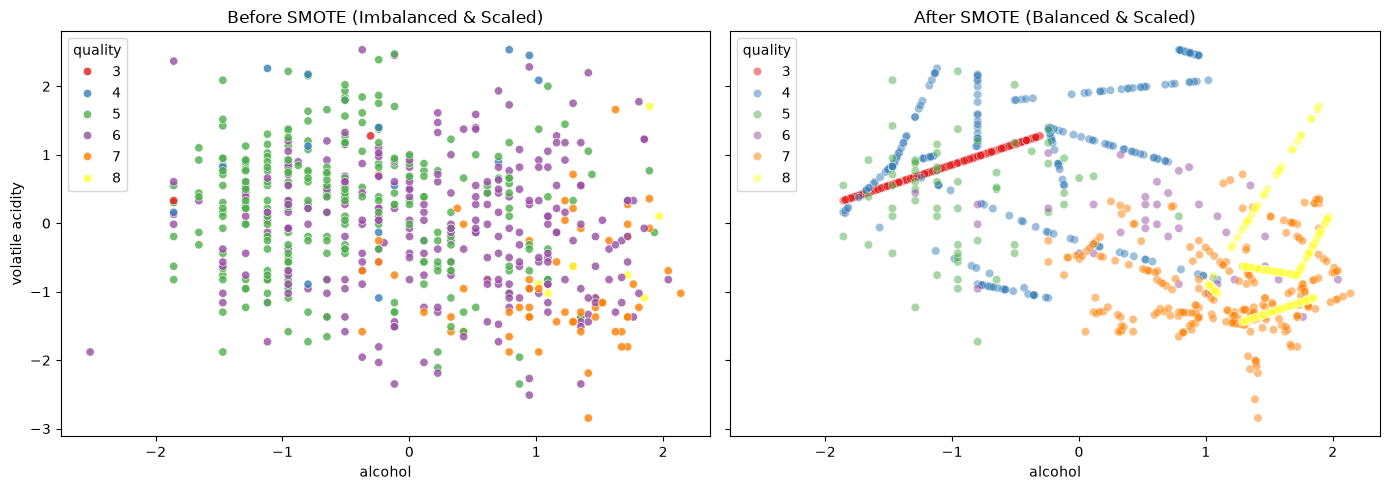

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert scaled arrays back to DataFrames for easier indexing
df_before = pd.DataFrame(X_train_scaled, columns=X_train.columns)
df_before['quality'] = y_train_clean.values

df_after = pd.DataFrame(X_train_resampled, columns=X_train.columns)
df_after['quality'] = y_train_resampled

# Compare side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

sns.scatterplot(
    data=df_before, x='alcohol', y='volatile acidity', 
    hue='quality', palette='Set1', ax=axes[0], alpha=0.8
)
axes[0].set_title('Before SMOTE (Imbalanced & Scaled)')

sns.scatterplot(
    data=df_after, x='alcohol', y='volatile acidity', 
    hue='quality', palette='Set1', ax=axes[1], alpha=0.5
)
axes[1].set_title('After SMOTE (Balanced & Scaled)')

plt.tight_layout()
plt.show()

well this looks so bad now XD

In [79]:
from imblearn.over_sampling import RandomOverSampler


ros = RandomOverSampler(random_state=42)

X_train_resampledROS, y_train_resampledROS = ros.fit_resample(X_train_scaled, y_train_clean)

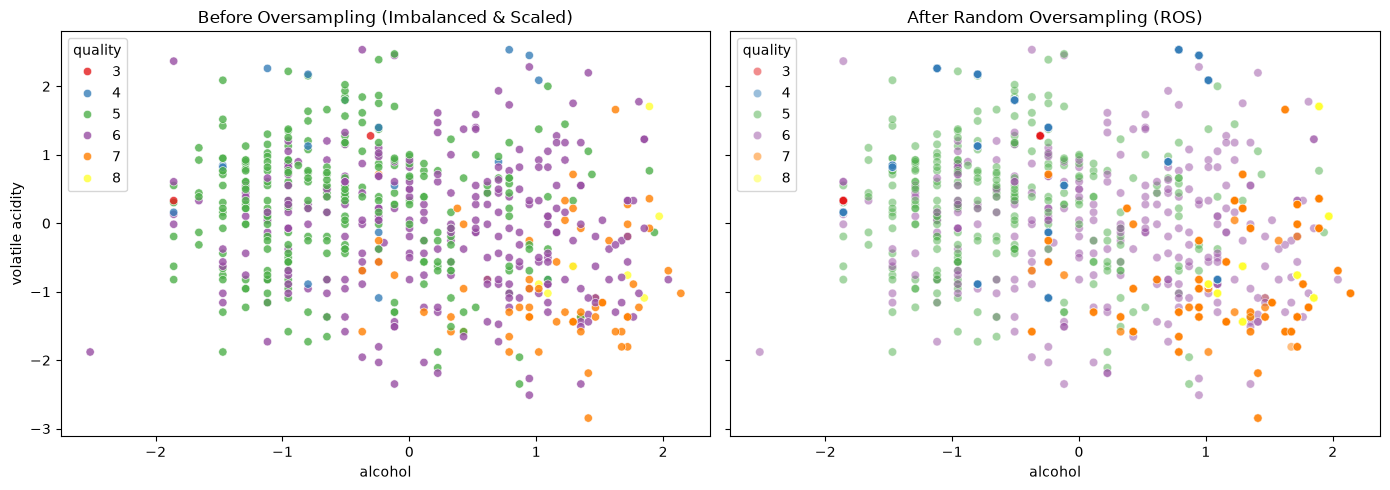

In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert original scaled array to DataFrame
df_before = pd.DataFrame(X_train_scaled, columns=X_train.columns)
df_before['quality'] = y_train_clean.values

# Convert ROS resampled array to DataFrame
df_after_ros = pd.DataFrame(X_train_resampledROS, columns=X_train.columns)
df_after_ros['quality'] = y_train_resampledROS

# Compare side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

sns.scatterplot(
    data=df_before, x='alcohol', y='volatile acidity', 
    hue='quality', palette='Set1', ax=axes[0], alpha=0.8
)
axes[0].set_title('Before Oversampling (Imbalanced & Scaled)')

sns.scatterplot(
    data=df_after_ros, x='alcohol', y='volatile acidity', 
    hue='quality', palette='Set1', ax=axes[1], alpha=0.5
)
axes[1].set_title('After Random Oversampling (ROS)')

plt.tight_layout()
plt.show()

In [81]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report

gnb_ros = GaussianNB()
gnb_ros.fit(X_train_resampledROS, y_train_resampledROS)

y_pred_ros = gnb_ros.predict(X_test_scaled)

print("=== GaussianNB with Random Oversampling ===")
print(classification_report(y_test, y_pred_ros))

=== GaussianNB with Random Oversampling ===
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.09      0.57      0.16         7
           5       0.65      0.45      0.53        86
           6       0.58      0.27      0.37        82
           7       0.23      0.46      0.31        24
           8       0.00      0.00      0.00         3

    accuracy                           0.37       203
   macro avg       0.26      0.29      0.23       203
weighted avg       0.54      0.37      0.42       203



the model scores suck but thats mostly cuz the model itself is not suitable for this type of problem, other classifiers would have worked way better with these type of data, NB is mostly for texts

In [ ]:
import numpy as np
import pandas as pd

def generate_samples_gnb(model, target_class, num_samples=100):
   
    class_idx = np.where(model.classes_ == target_class)[0][0]
    
   
    means = model.theta_[class_idx]
    variances = model.var_[class_idx]
    stds = np.sqrt(variances)
    
   
    synthetic_data = np.random.normal(
        loc=means, 
        scale=stds, 
        size=(num_samples, len(means))
    )
    
    return pd.DataFrame(synthetic_data, columns=X.columns)


synthetic_class_3 = generate_samples_gnb(gnb_ros, target_class=3, num_samples=50)
synthetic_class_3.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-1.473106,0.724661,0.635559,0.367344,-0.378770,-0.960118,-1.367124,1.060704,-0.975157,-0.360288,-1.085306
1,0.048199,0.894020,-1.585545,-0.759033,-0.245422,-1.006032,-0.957191,2.394533,-0.502489,0.320066,-0.239139
2,1.611864,0.103451,4.139285,0.146844,-0.156971,-0.916177,-1.680554,0.155199,1.475183,-0.402084,-2.211144
3,1.063436,1.287238,0.909724,0.025245,-0.356125,-0.925179,-0.493701,2.329717,0.752058,-0.620045,-0.239837
4,-1.063766,0.327740,-0.810371,0.489375,-0.114638,-0.883305,-1.333473,2.087525,0.892892,-0.232367,0.244106


i found a function that generates samples of a certain class